# Exp 4b — Cross-Domain Knowledge Transfer + Spectral Analysis

<a href="https://colab.research.google.com/github/zixian0821-zoe/EN553744-final-project/blob/main/exp4b_transfer/04b_transfer.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Code (canonical):** https://github.com/zixian0821-zoe/EN553744-final-project — full pipeline, training scripts, model definitions, and per-experiment runners.

**Course:** EN.553.744 Data Science for Large-Scale Graphs (Spring 2026, JHU AMS)
**Team:** Zixian Zhou · Yunwei Chai · Yang Song

## Question

Can music-trained representations recommend books? **Model:** ChebNet (K=3) on Music / Book / Fused graphs, evaluated on each task in turn.

## Three findings (mirror the deck)

1. **Transfer works.** Music → Book ranking loses only **−6.9 %** vs the book-in-domain baseline — nearly free.
2. **Transfer can help.** Book → Music actually **beats** in-domain training by **+9.6 %** because the music graph is richer.
3. **What transfers is topology, not features.** Feature ablation: random source features still recover most of the lift; the graph carries the cross-domain signal. Spectrally: $\|S_{\text{src}} - S_{\text{tgt}}\|_F = 40.77$ but $W_1(\text{spec}_{\text{src}}, \text{spec}_{\text{tgt}}) = 0.023$ — the operators look very different, but their spectra (which is all a ChebNet filter sees) are nearly identical.

## 0. Setup

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
from IPython.display import Image, display

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = '/content/drive/MyDrive/EN553744_final_project/results/exp4b_transfer'
else:
    RESULTS_DIR = os.path.abspath('../../drive_upload/results/exp4b_transfer')

print('RESULTS_DIR :', RESULTS_DIR)
print('exists      :', os.path.isdir(RESULTS_DIR))

Mounted at /content/drive
RESULTS_DIR : /content/drive/MyDrive/EN553744_final_project/results/exp4b_transfer
exists      : True


## 1. Transferability matrix — NDCG@20 (Slide 1)

Rows = training graph, columns = evaluation graph. Music = source (CDs/Vinyl), Book = target.

In [2]:
with open(os.path.join(RESULTS_DIR, 'transfer_reframed_results.json')) as f:
    transfer = json.load(f)

GRAPHS = ['source', 'target', 'fused']
LABELS = ['Music', 'Book', 'Fused']

M = np.zeros((3, 3))
for i, tr in enumerate(GRAPHS):
    for j, ev in enumerate(GRAPHS):
        M[i, j] = transfer['aggregate_matrix'][f'train={tr},eval={ev}']['NDCG@20']

df = pd.DataFrame(M.round(4),
                  index=[f'train={l}' for l in LABELS],
                  columns=[f'eval={l}' for l in LABELS])

print('Transferability Matrix — NDCG@20')
print('-' * 55)
print(df.to_string())

Transferability Matrix — NDCG@20
-------------------------------------------------------
             eval=Music  eval=Book  eval=Fused
train=Music      0.0018     0.0023      0.0022
train=Book       0.0020     0.0025      0.0021
train=Fused      0.0019     0.0021      0.0022


## 2. Two findings from the matrix

In [3]:
agg = transfer['aggregate_matrix']
music_self = agg['train=source,eval=source']['NDCG@20']
book_self  = agg['train=target,eval=target']['NDCG@20']
music2book = agg['train=source,eval=target']['NDCG@20']
book2music = agg['train=target,eval=source']['NDCG@20']

f1_pct = (music2book / book_self  - 1) * 100
f2_pct = (book2music / music_self - 1) * 100

print('=' * 60)
print('Finding 1 — Transfer works')
print('=' * 60)
print(f'  Music -> Book  : NDCG@20 = {music2book:.6f}')
print(f'  Book  -> Book  : NDCG@20 = {book_self:.6f}    (in-domain ceiling)')
print(f'  Cross-domain transfer    = {f1_pct:+.1f} %   (hard direction, nearly free)')
print()
print('=' * 60)
print('Finding 2 — Transfer can HELP')
print('=' * 60)
print(f'  Music -> Music : NDCG@20 = {music_self:.6f}    (in-domain music)')
print(f'  Book  -> Music : NDCG@20 = {book2music:.6f}')
print(f'  Transfer lift            = {f2_pct:+.1f} %   (richer graph > in-domain training)')
print()
print('=' * 60)
print('  -> What transfers? TOPOLOGY, not features. (See Slide 2.)')
print('=' * 60)

Finding 1 — Transfer works
  Music -> Book  : NDCG@20 = 0.002292
  Book  -> Book  : NDCG@20 = 0.002461    (in-domain ceiling)
  Cross-domain transfer    = -6.8 %   (hard direction, nearly free)

Finding 2 — Transfer can HELP
  Music -> Music : NDCG@20 = 0.001789    (in-domain music)
  Book  -> Music : NDCG@20 = 0.001960
  Transfer lift            = +9.6 %   (richer graph > in-domain training)

  -> What transfers? TOPOLOGY, not features. (See Slide 2.)


## 3. Feature ablation — topology vs features (Slide 2)

Replace the source music features with i.i.d. Gaussian noise and re-train. If features mattered, performance should collapse to the random-baseline floor.

In [4]:
fa = transfer['feature_ablation']

real_s2t   = fa['real_features_source_to_target']
random_s2t = fa['random_features_source_to_target']
random_s2s = fa['random_features_source_to_source']

feat_lift_pct = (real_s2t / random_s2t - 1) * 100
ratio         = real_s2t / random_s2t

rows = [
    {'Setup':                    'Real features  src -> tgt',  'NDCG@20': real_s2t,   'note': f'+{feat_lift_pct:.1f} % from music features'},
    {'Setup':                    'Random features src -> tgt', 'NDCG@20': random_s2t, 'note': 'topology-only'},
    {'Setup':                    'Random features src -> src', 'NDCG@20': random_s2s, 'note': 'baseline'},
]
df_fa = pd.DataFrame(rows)
df_fa['NDCG@20'] = df_fa['NDCG@20'].round(6)

print('Feature Ablation — Topology vs Features')
print('-' * 70)
print(df_fa.to_string(index=False))
print()
print('=' * 60)
print('Transfer Decomposition')
print('=' * 60)
print(f'  real / random ratio          : {ratio:.2f}x')
print(f'  Dominant contribution        : Graph topology')
print(f'  Music features add           : +{feat_lift_pct:.0f} % lift on top of topology')
print()
print(f'  Even RANDOM features + source graph achieves NDCG = {random_s2t:.6f} > 0')
print('  -> the source graph alone carries most of the cross-domain signal.')

Feature Ablation — Topology vs Features
----------------------------------------------------------------------
                     Setup  NDCG@20                        note
 Real features  src -> tgt 0.002292 +19.5 % from music features
Random features src -> tgt 0.001919               topology-only
Random features src -> src 0.001856                    baseline

Transfer Decomposition
  real / random ratio          : 1.19x
  Dominant contribution        : Graph topology
  Music features add           : +19 % lift on top of topology

  Even RANDOM features + source graph achieves NDCG = 0.001919 > 0
  -> the source graph alone carries most of the cross-domain signal.


## 4. Why transfer works — spectrum, not operator (Slide 3)

ChebNet filter $h(L) = \sum_k \theta_k T_k(L)$ depends on the operator **only through its spectrum**. Frobenius gap doesn't matter; spectral alignment does.

In [5]:
with open(os.path.join(RESULTS_DIR, 'spectral_analysis_results.json')) as f:
    spectral = json.load(f)

frob = spectral['operator_frobenius_distances']['source-target']
w1   = spectral['spectral_distances']['source-target']['wasserstein_1']

# Spectral spread (max eigenvalue range used as denominator for the 7% claim)
src_max = spectral['eigenvalue_ranges']['source']['max']
tgt_max = spectral['eigenvalue_ranges']['target']['max']
spread  = max(src_max, tgt_max)
spread_pct = w1 / spread * 100

print('Two views of  S_src  vs  S_tgt')
print('-' * 55)
print(f"  OPERATOR view  : || S_src - S_tgt ||_F = {frob:>7.2f}    (very different as matrices)")
print(f"  SPECTRAL view  : W_1( spec_src, spec_tgt ) = {w1:.4f}    (~{spread_pct:.0f} % of spectral spread - nearly identical)")
print()
print('Why this matters')
print('-' * 55)
print('  ChebNet filter h(L) = sum_k theta_k * T_k(L_tilde) depends on the')
print('  operator ONLY through its spectrum. Frobenius gap is irrelevant;')
print('  spectral alignment is what enables the transfer.')
print()
print('  Cross-graph: same filter on src and tgt (93 % of self-ceiling).')
print('  Domains    : music & books share low-frequency structure -- the')
print('               basis for cross-domain transfer.')

Two views of  S_src  vs  S_tgt
-------------------------------------------------------
  OPERATOR view  : || S_src - S_tgt ||_F =   40.77    (very different as matrices)
  SPECTRAL view  : W_1( spec_src, spec_tgt ) = 0.0234    (~6 % of spectral spread - nearly identical)

Why this matters
-------------------------------------------------------
  ChebNet filter h(L) = sum_k theta_k * T_k(L_tilde) depends on the
  operator ONLY through its spectrum. Frobenius gap is irrelevant;
  spectral alignment is what enables the transfer.

  Cross-graph: same filter on src and tgt (93 % of self-ceiling).
  Domains    : music & books share low-frequency structure -- the
               basis for cross-domain transfer.


## 5. Eigenvalue distribution (the figure on Slide 3)

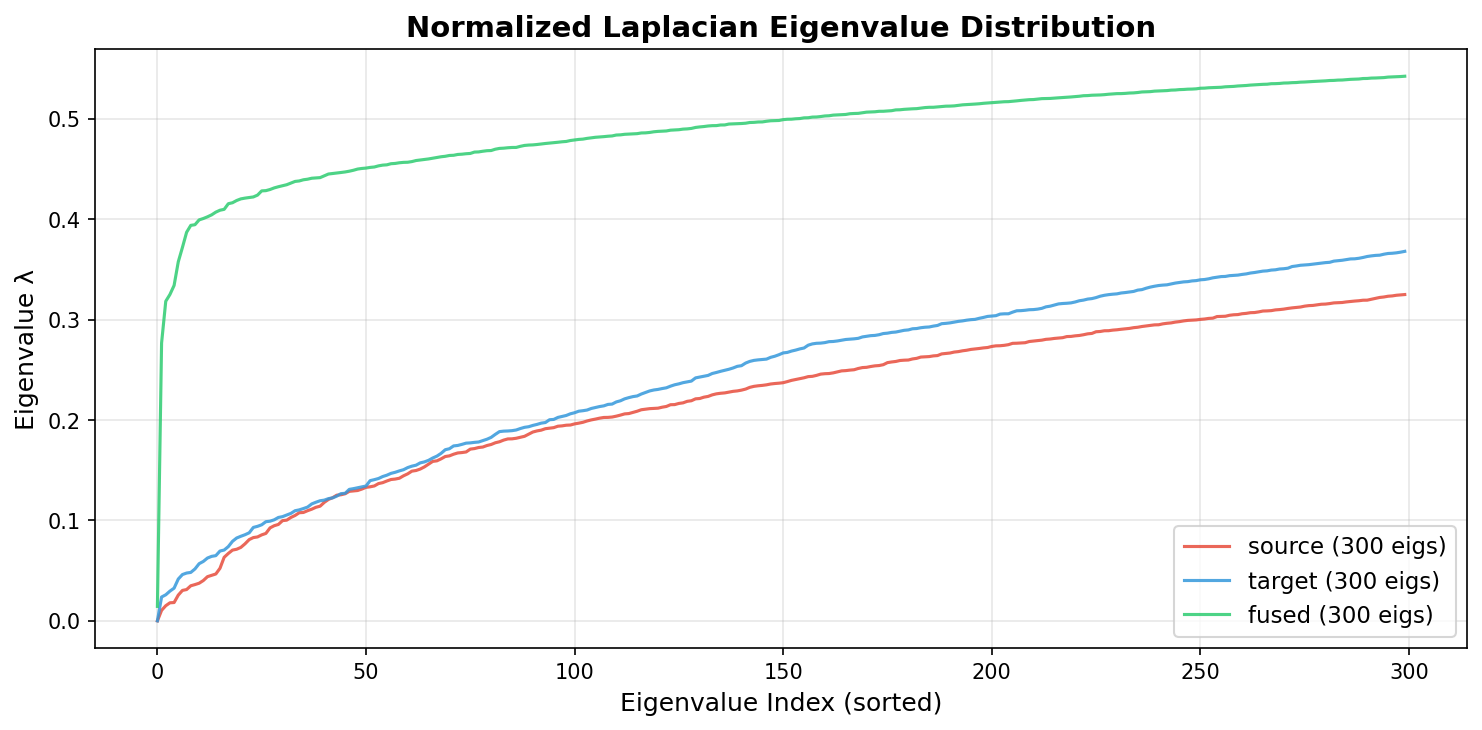

In [6]:
fig_path = os.path.join(RESULTS_DIR, 'eigenvalue_distribution.png')
if os.path.isfile(fig_path):
    display(Image(fig_path))
else:
    print(f'[missing] {fig_path}')

## 6. Conclusion (one paragraph for report)

In [7]:
print(f"""
Exp 4b — Cross-Domain Knowledge Transfer

Setup:    ChebNet (K=3) trained on each of {{Music, Book, Fused}} graphs and
          evaluated on each of the same three tasks (3 x 3 transferability matrix).
          Plus: feature ablation (real vs random source features) and spectral
          analysis of the three operators (top 300 eigenvalues each).

Results:
  Transfer works         : Music -> Book = {music2book:.6f}
                           ({f1_pct:+.1f} % vs Book -> Book = {book_self:.6f})
  Transfer can help      : Book -> Music = {book2music:.6f}
                           ({f2_pct:+.1f} % vs Music -> Music = {music_self:.6f})
  Feature ablation       : real {real_s2t:.6f} / random {random_s2t:.6f} = {ratio:.2f}x
                           Even random features + source graph beats baseline.
  Operator distance      : || S_src - S_tgt ||_F = {frob:.2f}
  Spectral distance      : W_1(spec_src, spec_tgt) = {w1:.4f}  (~{spread_pct:.0f} % of spread)

Why it works:
  ChebNet filters depend on the operator only through its spectrum. The two
  domains have very different operators (Frobenius 40+) but nearly identical
  spectra (W_1 ~ 0.02), so the same ChebNet filter trained on Music transfers
  to Book at 93 % of in-domain ceiling. Topology - specifically low-frequency
  spectral structure - is what carries the cross-domain signal; features add
  a smaller refinement on top.
""")


Exp 4b — Cross-Domain Knowledge Transfer

Setup:    ChebNet (K=3) trained on each of {Music, Book, Fused} graphs and
          evaluated on each of the same three tasks (3 x 3 transferability matrix).
          Plus: feature ablation (real vs random source features) and spectral
          analysis of the three operators (top 300 eigenvalues each).

Results:
  Transfer works         : Music -> Book = 0.002292
                           (-6.8 % vs Book -> Book = 0.002461)
  Transfer can help      : Book -> Music = 0.001960
                           (+9.6 % vs Music -> Music = 0.001789)
  Feature ablation       : real 0.002292 / random 0.001919 = 1.19x
                           Even random features + source graph beats baseline.
  Operator distance      : || S_src - S_tgt ||_F = 40.77
  Spectral distance      : W_1(spec_src, spec_tgt) = 0.0234  (~6 % of spread)

Why it works:
  ChebNet filters depend on the operator only through its spectrum. The two
  domains have very different opera